In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: seasonal decomposition if statsmodels is installed
try:
    from statsmodels.tsa.seasonal import seasonal_decompose
    statsmodels_installed = True
except ModuleNotFoundError:
    print("Warning: statsmodels not installed. Seasonal decomposition will be skipped.")
    statsmodels_installed = False

%matplotlib inline


In [2]:
file_path = "AirQuality.csv"  # update path if needed

# Read CSV with semicolon delimiter
df = pd.read_csv(file_path, delimiter=';', decimal='.', skipinitialspace=True)

# Inspect first few rows
print("First 5 rows of raw data:")
display(df.head())


First 5 rows of raw data:


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578",NaN,NaN
1,10/03/2004,19.00.00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255",NaN,NaN
2,10/03/2004,20.00.00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502",NaN,NaN
3,10/03/2004,21.00.00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867",NaN,NaN
4,10/03/2004,22.00.00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888",NaN,NaN


In [3]:
# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Remove extra spaces from string values
df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)

# Inspect column types
print("Column dtypes after stripping:")
print(df.dtypes)


Column dtypes after stripping:
Date              object
Time              object
CO(GT)            object
PT08.S1(CO)      float64
NMHC(GT)         float64
C6H6(GT)          object
PT08.S2(NMHC)    float64
NOx(GT)          float64
PT08.S3(NOx)     float64
NO2(GT)          float64
PT08.S4(NO2)     float64
PT08.S5(O3)      float64
T                 object
RH                object
AH                object
Unnamed: 15      float64
Unnamed: 16      float64
dtype: object


In [4]:
if 'Date' in df.columns and 'Time' in df.columns:
    df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], errors='coerce', dayfirst=True)
    
    # Check conversion
    print("Datetime conversion nulls:", df['Datetime'].isna().sum())
    
    # Optional: inspect first 10 rows
    display(df[['Date', 'Time', 'Datetime']].head(10))
    
    # Drop original Date/Time
    df.drop(columns=['Date','Time'], inplace=True)
    
    # Drop rows where Datetime failed
    df = df.dropna(subset=['Datetime'])
    print("Shape after datetime cleaning:", df.shape)


Datetime conversion nulls: 9471


,Date,Time,Datetime
0,10/03/2004,18.00.00,NaT
1,10/03/2004,19.00.00,NaT
2,10/03/2004,20.00.00,NaT
3,10/03/2004,21.00.00,NaT
4,10/03/2004,22.00.00,NaT
5,10/03/2004,23.00.00,NaT
6,11/03/2004,00.00.00,NaT
7,11/03/2004,01.00.00,NaT
8,11/03/2004,02.00.00,NaT
9,11/03/2004,03.00.00,NaT


Shape after datetime cleaning: (0, 16)


In [5]:
# Replace dots with colons in Time
df['Time'] = df['Time'].str.replace('.', ':', regex=False)

# Now convert Date + Time to datetime
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True, errors='coerce')

# Check conversion
print(df[['Date','Time','Datetime']].head(10))
print("Datetime conversion nulls:", df['Datetime'].isna().sum())

# Drop rows with invalid datetime if any remain
df = df.dropna(subset=['Datetime'])
print("Shape after datetime cleaning:", df.shape)


KeyError: 'Time'

In [6]:
# Strip all column names
df.columns = df.columns.str.strip()

# Check if Date and Time exist
if 'Date' in df.columns and 'Time' in df.columns:
    # Fix Time format (dots → colons)
    df['Time'] = df['Time'].str.replace('.', ':', regex=False)
    
    # Convert to datetime
    df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True, errors='coerce')
    print(df[['Date','Time','Datetime']].head(10))
    
    # Drop original Date/Time columns if desired
    df.drop(columns=['Date','Time'], inplace=True)
    
    # Drop rows where datetime failed
    df = df.dropna(subset=['Datetime'])
    print("Shape after datetime cleaning:", df.shape)
else:
    print("Error: 'Date' or 'Time' column not found. Available columns:", df.columns.tolist())


Error: 'Date' or 'Time' column not found. Available columns: ['CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH', 'Unnamed: 15', 'Unnamed: 16', 'Datetime']


In [7]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]


In [8]:
df['Datetime'] = pd.to_datetime(df['Datetime'], errors='coerce')

# Drop rows with invalid Datetime if any
df = df.dropna(subset=['Datetime'])


In [9]:
numeric_cols = df.columns.drop('Datetime')

# Convert to numeric, handle commas and spaces
df[numeric_cols] = df[numeric_cols].apply(
    lambda x: pd.to_numeric(x.astype(str).str.replace(',', '.').str.strip(), errors='coerce')
)

# Fill missing values
df = df.fillna(method='ffill').fillna(method='bfill')

# Verify
print(df.dtypes)
print(df.head())


CO(GT)                   object
PT08.S1(CO)             float64
NMHC(GT)                float64
C6H6(GT)                 object
PT08.S2(NMHC)           float64
NOx(GT)                 float64
PT08.S3(NOx)            float64
NO2(GT)                 float64
PT08.S4(NO2)            float64
PT08.S5(O3)             float64
T                        object
RH                       object
AH                       object
Datetime         datetime64[ns]
dtype: object
Empty DataFrame
Columns: [CO(GT), PT08.S1(CO), NMHC(GT), C6H6(GT), PT08.S2(NMHC), NOx(GT), PT08.S3(NOx), NO2(GT), PT08.S4(NO2), PT08.S5(O3), T, RH, AH, Datetime]
Index: []


In [10]:
# Keep only necessary columns
df = df[['Datetime','CO(GT)','C6H6(GT)','T','RH','AH','PT08.S1(CO)','NMHC(GT)',
         'PT08.S2(NMHC)','NOx(GT)','PT08.S3(NOx)','NO2(GT)','PT08.S4(NO2)','PT08.S5(O3)']]

# Replace commas with dots and strip spaces for all object columns
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].str.replace(',', '.').str.strip()

# Convert all columns except Datetime to numeric
numeric_cols = df.columns.drop('Datetime')
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')


In [11]:
print("Missing values per column:")
print(df.isna().sum())


Missing values per column:
Datetime         0.0
CO(GT)           0.0
C6H6(GT)         0.0
T                0.0
RH               0.0
AH               0.0
PT08.S1(CO)      0.0
NMHC(GT)         0.0
PT08.S2(NMHC)    0.0
NOx(GT)          0.0
PT08.S3(NOx)     0.0
NO2(GT)          0.0
PT08.S4(NO2)     0.0
PT08.S5(O3)      0.0
dtype: float64


In [12]:
df = df.fillna(method='ffill').fillna(method='bfill')


In [13]:
print(df.dtypes)
print(df.head())
display(df.describe())


Datetime         datetime64[ns]
CO(GT)                   object
C6H6(GT)                 object
T                        object
RH                       object
AH                       object
PT08.S1(CO)             float64
NMHC(GT)                float64
PT08.S2(NMHC)           float64
NOx(GT)                 float64
PT08.S3(NOx)            float64
NO2(GT)                 float64
PT08.S4(NO2)            float64
PT08.S5(O3)             float64
dtype: object
Empty DataFrame
Columns: [Datetime, CO(GT), C6H6(GT), T, RH, AH, PT08.S1(CO), NMHC(GT), PT08.S2(NMHC), NOx(GT), PT08.S3(NOx), NO2(GT), PT08.S4(NO2), PT08.S5(O3)]
Index: []


,PT08.S1(CO),NMHC(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3)
count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
# Remove unwanted unnamed columns
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Strip strings and replace comma with dot in object columns
for col in ['CO(GT)','C6H6(GT)','T','RH','AH']:
    df[col] = df[col].astype(str).str.replace(',', '.').str.strip()

# Convert all numeric columns to float
numeric_cols = df.columns.drop('Datetime')
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

# Fill missing values
df = df.fillna(method='ffill').fillna(method='bfill')

# Verify
print(df.dtypes)
print(df.head())
display(df.describe())


Datetime         datetime64[ns]
CO(GT)                   object
C6H6(GT)                 object
T                        object
RH                       object
AH                       object
PT08.S1(CO)             float64
NMHC(GT)                float64
PT08.S2(NMHC)           float64
NOx(GT)                 float64
PT08.S3(NOx)            float64
NO2(GT)                 float64
PT08.S4(NO2)            float64
PT08.S5(O3)             float64
dtype: object
Empty DataFrame
Columns: [Datetime, CO(GT), C6H6(GT), T, RH, AH, PT08.S1(CO), NMHC(GT), PT08.S2(NMHC), NOx(GT), PT08.S3(NOx), NO2(GT), PT08.S4(NO2), PT08.S5(O3)]
Index: []


,PT08.S1(CO),NMHC(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3)
count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
print(df[['CO(GT)', 'C6H6(GT)', 'T', 'RH', 'AH']].head(10))


Empty DataFrame
Columns: [CO(GT), C6H6(GT), T, RH, AH]
Index: []


In [16]:
with open("AirQuality.csv", "r") as f:
    for i in range(10):
        print(f.readline())


Date;Time;CO(GT);PT08.S1(CO);NMHC(GT);C6H6(GT);PT08.S2(NMHC);NOx(GT);PT08.S3(NOx);NO2(GT);PT08.S4(NO2);PT08.S5(O3);T;RH;AH;;

10/03/2004;18.00.00;2,6;1360;150;11,9;1046;166;1056;113;1692;1268;13,6;48,9;0,7578;;

10/03/2004;19.00.00;2;1292;112;9,4;955;103;1174;92;1559;972;13,3;47,7;0,7255;;

10/03/2004;20.00.00;2,2;1402;88;9,0;939;131;1140;114;1555;1074;11,9;54,0;0,7502;;

10/03/2004;21.00.00;2,2;1376;80;9,2;948;172;1092;122;1584;1203;11,0;60,0;0,7867;;

10/03/2004;22.00.00;1,6;1272;51;6,5;836;131;1205;116;1490;1110;11,2;59,6;0,7888;;

10/03/2004;23.00.00;1,2;1197;38;4,7;750;89;1337;96;1393;949;11,2;59,2;0,7848;;

11/03/2004;00.00.00;1,2;1185;31;3,6;690;62;1462;77;1333;733;11,3;56,8;0,7603;;

11/03/2004;01.00.00;1;1136;31;3,3;672;62;1453;76;1333;730;10,7;60,0;0,7702;;

11/03/2004;02.00.00;0,9;1094;24;2,3;609;45;1579;60;1276;620;10,7;59,7;0,7648;;



In [17]:
df = pd.read_csv("AirQuality.csv", 
                 sep=';', 
                 decimal=',', 
                 skipinitialspace=True, 
                 na_values=-200)


In [18]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]


In [19]:
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'].str.replace('.', ':'),
                                dayfirst=True, errors='coerce')
df.drop(columns=['Date','Time'], inplace=True)
df = df.dropna(subset=['Datetime'])


c:\program files\python37\lib\site-packages\ipykernel_launcher.py:1: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
  """Entry point for launching an IPython kernel.


In [20]:
# Replace dot with colon in Time
df['Time'] = df['Time'].str.replace('.', ':', regex=False)

# Combine Date + Time into Datetime
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True, errors='coerce')

# Drop original columns and invalid datetimes
df.drop(columns=['Date', 'Time'], inplace=True)
df = df.dropna(subset=['Datetime'])

print(df['Datetime'].head())
print("Shape after datetime cleaning:", df.shape)


KeyError: 'Time'

In [21]:
import pandas as pd
import numpy as np

# Step 1: Load CSV correctly
df = pd.read_csv("AirQuality.csv", sep=';', decimal=',', skipinitialspace=True, na_values=-200)

# Step 2: Drop unnamed/empty columns
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Step 3: Ensure Datetime column is datetime type
df['Datetime'] = pd.to_datetime(df['Datetime'], errors='coerce')
df = df.dropna(subset=['Datetime'])

# Step 4: Convert numeric columns
numeric_cols = ['CO(GT)', 'C6H6(GT)', 'T', 'RH', 'AH', 
                'PT08.S1(CO)','NMHC(GT)','PT08.S2(NMHC)','NOx(GT)',
                'PT08.S3(NOx)','NO2(GT)','PT08.S4(NO2)','PT08.S5(O3)']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Step 5: Fill missing values
df = df.fillna(method='ffill').fillna(method='bfill')

# Step 6: Verify
print(df.dtypes)
print(df.shape)
print(df.head())
display(df.describe())


KeyError: 'Datetime'

In [22]:
import pandas as pd
import numpy as np

# Load CSV
df = pd.read_csv("AirQuality.csv", sep=';', decimal=',', skipinitialspace=True, na_values=-200)

# Drop unnamed/empty columns
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# List of numeric columns (all columns except any known non-numeric)
numeric_cols = ['CO(GT)', 'C6H6(GT)', 'T', 'RH', 'AH', 
                'PT08.S1(CO)','NMHC(GT)','PT08.S2(NMHC)','NOx(GT)',
                'PT08.S3(NOx)','NO2(GT)','PT08.S4(NO2)','PT08.S5(O3)']

# Convert to numeric
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Fill missing values
df = df.fillna(method='ffill').fillna(method='bfill')

# Verify
print(df.dtypes)
print(df.shape)
print(df.head())
display(df.describe())


Date              object
Time              object
CO(GT)           float64
PT08.S1(CO)      float64
NMHC(GT)         float64
C6H6(GT)         float64
PT08.S2(NMHC)    float64
NOx(GT)          float64
PT08.S3(NOx)     float64
NO2(GT)          float64
PT08.S4(NO2)     float64
PT08.S5(O3)      float64
T                float64
RH               float64
AH               float64
dtype: object
(9471, 15)
         Date      Time  CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  \
0  10/03/2004  18.00.00     2.6       1360.0     150.0      11.9   
1  10/03/2004  19.00.00     2.0       1292.0     112.0       9.4   
2  10/03/2004  20.00.00     2.2       1402.0      88.0       9.0   
3  10/03/2004  21.00.00     2.2       1376.0      80.0       9.2   
4  10/03/2004  22.00.00     1.6       1272.0      51.0       6.5   

   PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)  \
0         1046.0    166.0        1056.0    113.0        1692.0       1268.0   
1          955.0    103.0        

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,9471.000000,9471.000000,9471.000000,9471.000000,9471.000000,9471.000000,9471.000000,9471.000000,9471.000000,9471.000000,9471.000000,9471.000000,9471.000000
mean,2.083613,1102.348432,270.550945,10.210970,943.805512,241.023334,830.590751,110.120051,1449.114455,1027.929891,18.439922,48.387509,1.011188
std,1.460984,218.289826,72.865938,7.522406,268.195857,205.388102,254.912036,47.369418,347.139644,409.105364,8.838660,17.683879,0.406279
min,0.100000,647.000000,7.000000,0.100000,383.000000,2.000000,322.000000,2.000000,551.000000,221.000000,-1.900000,9.200000,0.184700
25%,1.000000,940.000000,275.000000,4.400000,734.000000,98.000000,654.000000,74.000000,1215.000000,729.000000,11.900000,34.900000,0.715000
50%,1.700000,1065.000000,275.000000,8.400000,915.000000,176.000000,803.000000,103.000000,1455.000000,958.000000,17.700000,48.600000,0.981200
75%,2.700000,1235.000000,275.000000,13.900000,1113.500000,316.000000,964.000000,139.000000,1675.000000,1281.000000,24.600000,61.700000,1.301900
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000


In [23]:
# Combine Date + Time into a single Datetime column
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'].str.replace('.', ':', regex=False),
                                dayfirst=True, errors='coerce')

# Drop rows where Datetime conversion failed
df = df.dropna(subset=['Datetime'])

# Set Datetime as index (optional for time-series)
df = df.set_index('Datetime')

print(df.head())


                           Date      Time  CO(GT)  PT08.S1(CO)  NMHC(GT)  \
Datetime                                                                   
2004-03-10 18:00:00  10/03/2004  18.00.00     2.6       1360.0     150.0   
2004-03-10 19:00:00  10/03/2004  19.00.00     2.0       1292.0     112.0   
2004-03-10 20:00:00  10/03/2004  20.00.00     2.2       1402.0      88.0   
2004-03-10 21:00:00  10/03/2004  21.00.00     2.2       1376.0      80.0   
2004-03-10 22:00:00  10/03/2004  22.00.00     1.6       1272.0      51.0   

                     C6H6(GT)  PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  NO2(GT)  \
Datetime                                                                       
2004-03-10 18:00:00      11.9         1046.0    166.0        1056.0    113.0   
2004-03-10 19:00:00       9.4          955.0    103.0        1174.0     92.0   
2004-03-10 20:00:00       9.0          939.0    131.0        1140.0    114.0   
2004-03-10 21:00:00       9.2          948.0    172.0        1092.0

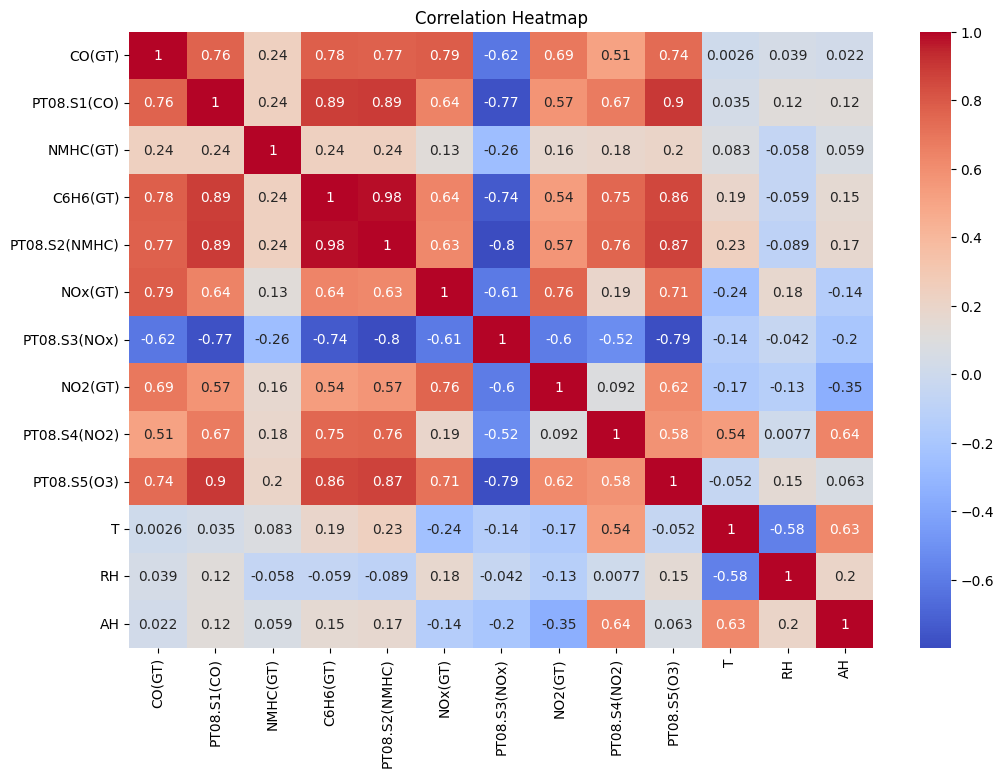

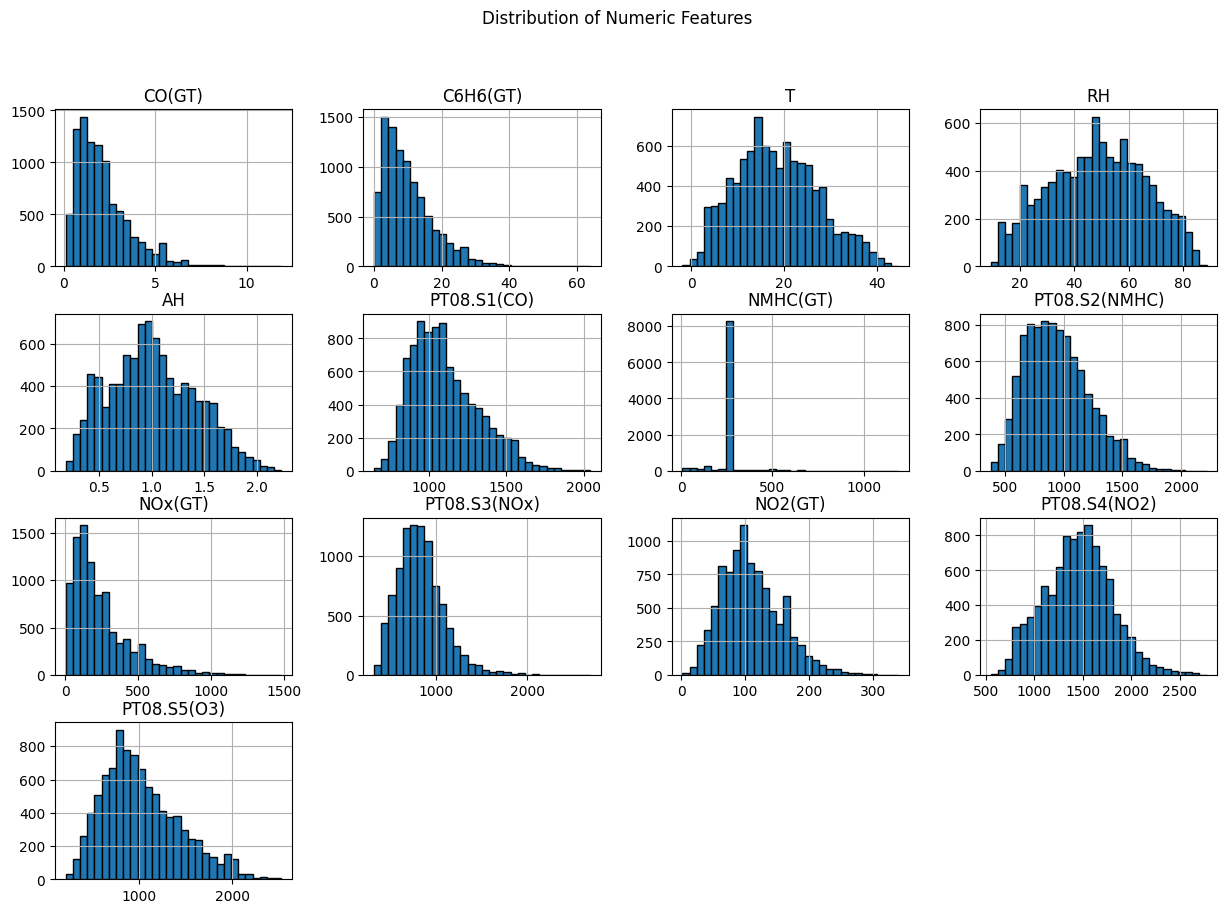

Number of outliers in CO(GT): 461


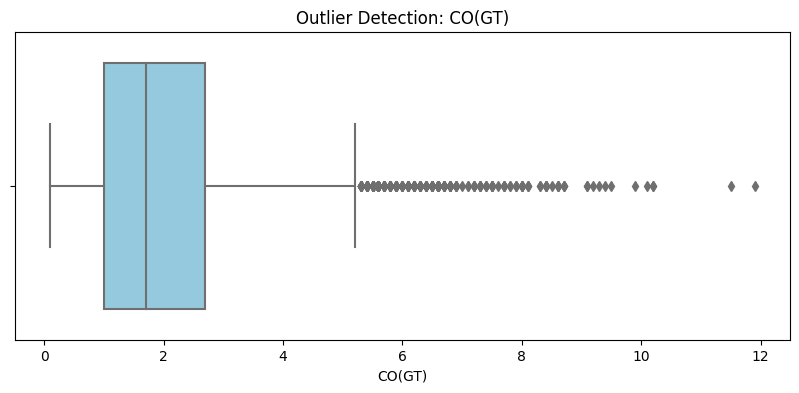

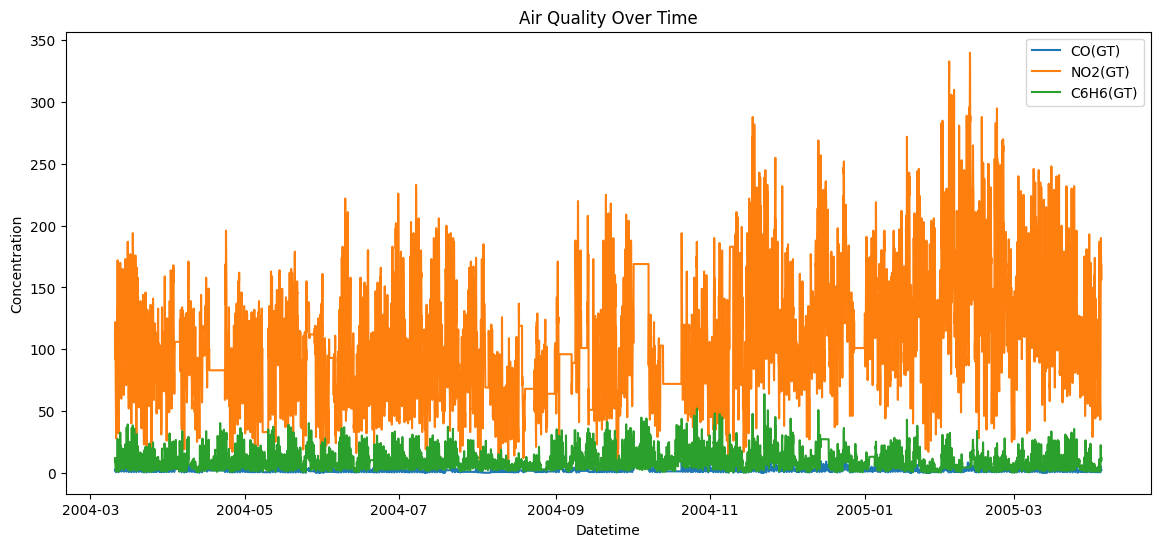

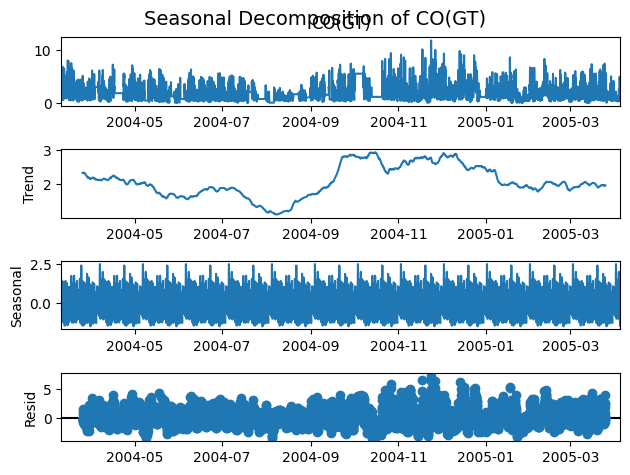

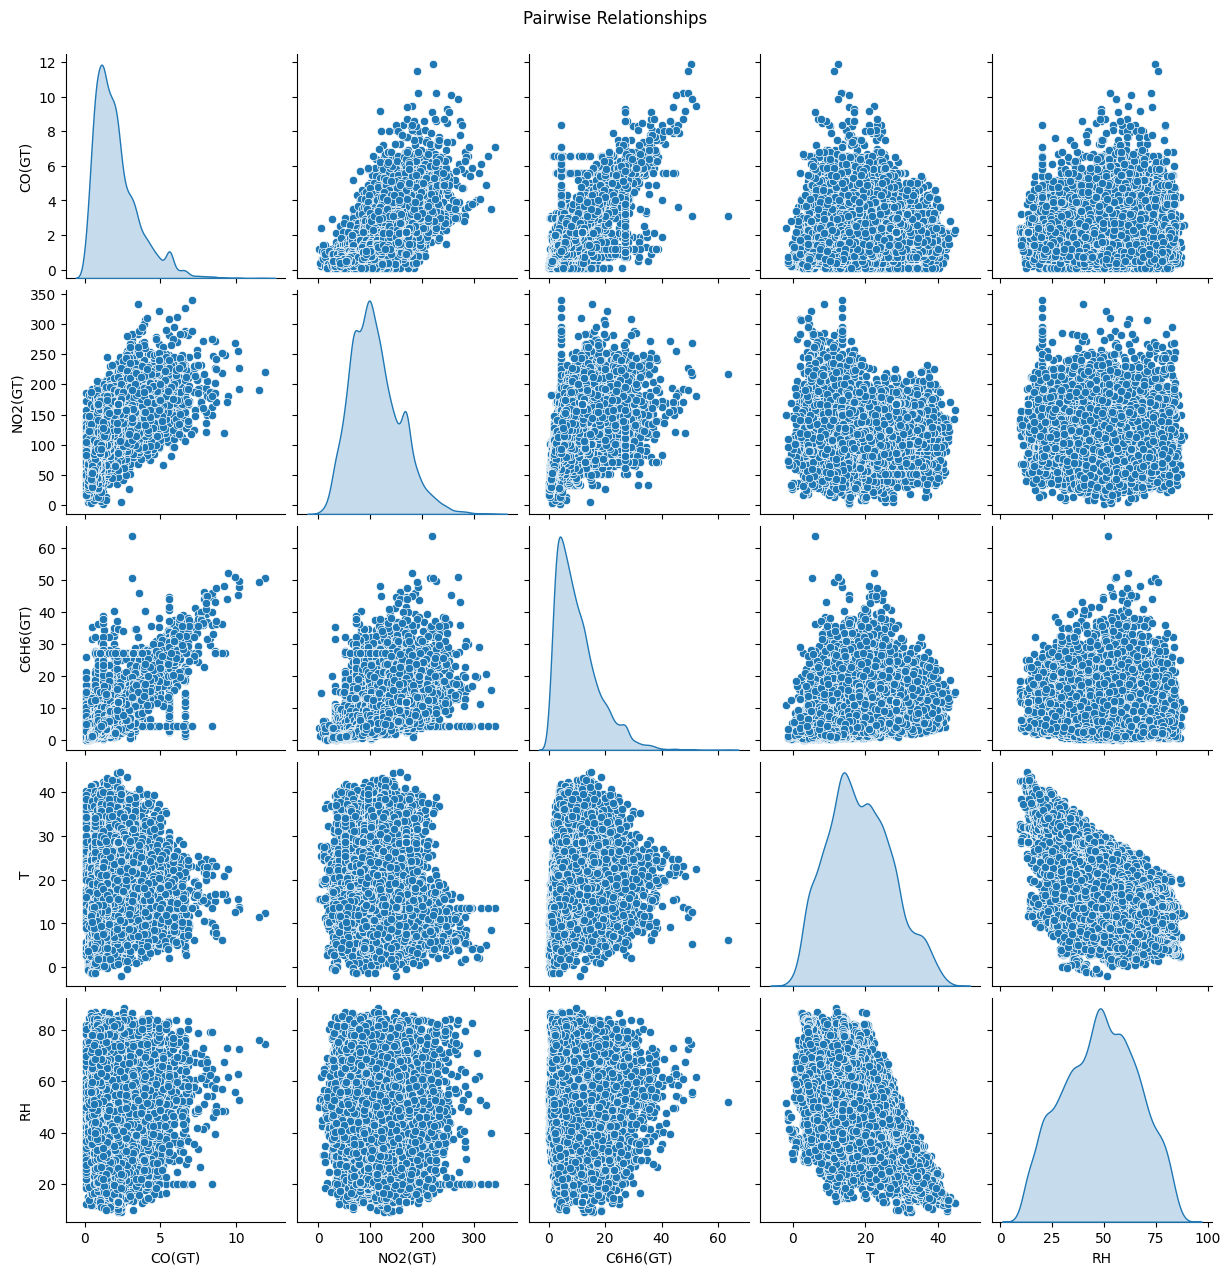

In [24]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), cmap='coolwarm', annot=True)
plt.title("Correlation Heatmap")
plt.show()

# --- Distribution Plots for Key Features ---
df[numeric_cols].hist(bins=30, figsize=(15, 10), edgecolor='black')
plt.suptitle("Distribution of Numeric Features")
plt.show()

# --- Outlier Detection using IQR ---
def detect_outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower) | (data[col] > upper)]
    return outliers

# Example: Outliers for CO(GT)
outliers = detect_outliers_iqr(df, 'CO(GT)')
print(f"Number of outliers in CO(GT): {len(outliers)}")

plt.figure(figsize=(10, 4))
sns.boxplot(x=df['CO(GT)'], color='skyblue')
plt.title("Outlier Detection: CO(GT)")
plt.show()

# --- Time-Series Trend Visualization ---
plt.figure(figsize=(14, 6))
for col in ['CO(GT)', 'NO2(GT)', 'C6H6(GT)']:
    if col in df.columns:
        plt.plot(df.index, df[col], label=col)
plt.legend()
plt.xlabel("Datetime")
plt.ylabel("Concentration")
plt.title("Air Quality Over Time")
plt.show()

# --- Seasonal Decomposition Example (CO(GT)) ---
if 'CO(GT)' in df.columns:
    df['CO(GT)'] = df['CO(GT)'].interpolate(method='time')  # Interpolate missing values
    result = seasonal_decompose(df['CO(GT)'], model='additive', period=24*30)  # ~1 month
    result.plot()
    plt.suptitle("Seasonal Decomposition of CO(GT)", fontsize=14)
    plt.show()

# --- Pairplot for Relationships ---
selected_cols = ['CO(GT)', 'NO2(GT)', 'C6H6(GT)', 'T', 'RH']
subset = [col for col in selected_cols if col in df.columns]
if len(subset) >= 2:
    sns.pairplot(df[subset], diag_kind='kde')
    plt.suptitle("Pairwise Relationships", y=1.02)
    plt.show()
